In [30]:
import xarray as xr
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# 1. Load the NetCDF files
features_ds = xr.open_dataset("features_normalized.nc")
target_ds = xr.open_dataset("target_normalized.nc")
mask_ds = xr.open_dataset("ocean_mask_3d.nc")

display(features_ds)
display(target_ds)
display(mask_ds)

<xarray.Dataset> Size: 19MB
Dimensions:       (time: 1096, latitude: 25, longitude: 25)
Coordinates:
  * time          (time) datetime64[ns] 9kB 2020-01-01 2020-01-02 ... 2022-12-31
  * latitude      (latitude) float32 100B 18.0 18.25 18.5 ... 23.5 23.75 24.0
  * longitude     (longitude) float32 100B 67.0 67.25 67.5 ... 72.5 72.75 73.0
    depth         int32 4B ...
Data variables:
    analysed_sst  (time, latitude, longitude) float32 3MB ...
    sos           (time, latitude, longitude) float32 3MB ...
    sla           (time, latitude, longitude) float32 3MB ...
    uwnd          (time, latitude, longitude) float32 3MB ...
    vwnd          (time, latitude, longitude) float32 3MB ...
    u             (time, latitude, longitude) float32 3MB ...
    v             (time, latitude, longitude) float32 3MB ...
Attributes: (12/48)
    Conventions:                CF-1.4, ACDD-1.3
    Metadata_Conventions:       Unidata Observation Dataset v1.0
    acknowledgment:             Please acknowledge the use of these data with...
    cdm_data_type:              grid
    comment:                    WARNING Some applications are unable to prope...
    creator_email:              servicedesk.cmems@mercator-ocean.eu
    ...                         ...
    time_coverage_end:          19811002T000000Z
    time_coverage_start:        19811001T000000Z
    title:                      Global SST & Sea Ice Analysis, L4 OSTIA, 0.05...
    uuid:                       a2df4a18-6f19-4772-9532-39307a0e2794
    westernmost_longitude:      -180.0
    copernicusmarine_version:   2.4.1

<xarray.Dataset> Size: 41MB
Dimensions:    (time: 1096, depth: 15, latitude: 25, longitude: 25)
Coordinates:
  * time       (time) datetime64[ns] 9kB 2020-01-01 2020-01-02 ... 2022-12-31
  * depth      (depth) int32 60B 0 5 10 20 30 50 75 ... 150 200 300 500 700 1000
  * latitude   (latitude) float32 100B 18.0 18.25 18.5 18.75 ... 23.5 23.75 24.0
  * longitude  (longitude) float32 100B 67.0 67.25 67.5 ... 72.5 72.75 73.0
Data variables:
    thetao     (time, depth, latitude, longitude) float32 41MB ...
Attributes: (12/25)
    Conventions:               CF-1.4
    bulletin_date:             2021-07-07 00:00:00
    bulletin_type:             operational
    comment:                   CMEMS product
    domain_name:               GL12
    easting:                   longitude
    ...                        ...
    references:                http://www.mercator-ocean.fr
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    z_max:                     5727.9169921875
    z_min:                     0.49402499198913574
    copernicusmarine_version:  2.4.1

<xarray.Dataset> Size: 75kB
Dimensions:     (depth: 15, latitude: 25, longitude: 25)
Coordinates:
  * depth       (depth) int32 60B 0 5 10 20 30 50 ... 150 200 300 500 700 1000
  * latitude    (latitude) float32 100B 18.0 18.25 18.5 ... 23.5 23.75 24.0
  * longitude   (longitude) float32 100B 67.0 67.25 67.5 ... 72.5 72.75 73.0
Data variables:
    ocean_mask  (depth, latitude, longitude) int64 75kB ...

In [31]:
# Extract the 7 feature variables into a single numpy array
# Shape will be: (1096, 7, 25, 25)
feature_vars = ['analysed_sst', 'sos', 'sla', 'uwnd', 'vwnd', 'u', 'v']
features_array = np.stack([features_ds[var].values for var in feature_vars], axis=1)

# xtract target temperatures and the 3D mask
# Target shape: (1096, 15, 25, 25) | Mask shape: (15, 25, 25)
targets_array = target_ds['thetao'].values
mask_3d_array = mask_ds['ocean_mask'].values

In [32]:
# Convert everything to PyTorch Tensors (float32 is standard for neural networks)
features_tensor = torch.tensor(features_array, dtype=torch.float32)
targets_tensor = torch.tensor(targets_array, dtype=torch.float32)
mask_3d_tensor = torch.tensor(mask_3d_array, dtype=torch.float32)

print(f"Features shape: {features_tensor.shape}")
print(f"Targets shape: {targets_tensor.shape}")
print(f"Mask 3D shape: {mask_3d_tensor.shape}")

Features shape: torch.Size([1096, 7, 25, 25])
Targets shape: torch.Size([1096, 15, 25, 25])
Mask 3D shape: torch.Size([15, 25, 25])


In [33]:
import torch
from torch.utils.data import Dataset

class OceanSequenceDataset(Dataset):
    def __init__(self, features, targets, mask_3d, seq_length=10):
        self.features = features
        self.targets = targets
        self.mask_3d = mask_3d
        self.seq_length = seq_length
        
        # The 2D surface mask is just the top layer (depth 0) of your 3D mask
        self.mask_2d = self.mask_3d[0] # Shape: (25, 25)

    def __len__(self):
        # If we have 1096 days and need 10 days of history to predict day 11,
        # we can make (1096 - 10) total samples.
        return len(self.features) - self.seq_length

    def __getitem__(self, idx):
        # 1. Grab the 10-day historical window
        # Shape: (10, 7, 25, 25)
        x_hist = self.features[idx : idx + self.seq_length]
        
        # 2. Grab Day 11 Surface Weather
        # Shape: (7, 25, 25)
        x_target_day_features = self.features[idx + self.seq_length]
        
        # 3. Grab the target depths (Day 11)
        # Shape: (15, 25, 25)
        y_target = self.targets[idx + self.seq_length]
        
        # 4. Expand mask for the historical sequence and concatenate
        # Final shape: (10, 8, 25, 25)
        mask_2d_expanded = self.mask_2d.unsqueeze(0).unsqueeze(0).expand(self.seq_length, 1, -1, -1)
        x_final_hist = torch.cat([x_hist, mask_2d_expanded], dim=1)
        
        # 5. Add mask to the Target Day weather
        # Shape: (1, 25, 25) -> concatenate to make (8, 25, 25)
        mask_2d_single = self.mask_2d.unsqueeze(0)
        x_final_target = torch.cat([x_target_day_features, mask_2d_single], dim=0)
        
        # Return all three components
        return x_final_hist, x_final_target, y_target

In [35]:
# Create the Dataset
ocean_dataset = OceanSequenceDataset(
    features=features_tensor, 
    targets=targets_tensor, 
    mask_3d=mask_3d_tensor, 
    seq_length=10
)

# Create the DataLoader 
train_loader = DataLoader(ocean_dataset, batch_size=4, shuffle=True, drop_last=True)

# Test the pipeline by grabbing the very first batch
for batch_x_hist, batch_x_target, batch_y in train_loader:
    print("\n--- Pipeline Dry Run ---")
    print(f"Historical Input (M1/M2): {batch_x_hist.shape}  -> (Batch, Time, Channels, Lat, Lon)")
    print(f"Target Day Weather (M3):  {batch_x_target.shape}   -> (Batch, Channels, Lat, Lon)")
    print(f"Target Subsurface (M4):   {batch_y.shape}  -> (Batch, Depth, Lat, Lon)")
    
    print(f"\nStatic 3D Mask Shape:     {mask_3d_tensor.shape}")
    break


--- Pipeline Dry Run ---
Historical Input (M1/M2): torch.Size([4, 10, 8, 25, 25])  -> (Batch, Time, Channels, Lat, Lon)
Target Day Weather (M3):  torch.Size([4, 8, 25, 25])   -> (Batch, Channels, Lat, Lon)
Target Subsurface (M4):   torch.Size([4, 15, 25, 25])  -> (Batch, Depth, Lat, Lon)

Static 3D Mask Shape:     torch.Size([15, 25, 25])


### Module 1: Temporal Scale (TS) Mixer

This module acts as a "time slicer" to process the 10-day historical sequence of ocean surface variables. Because ocean dynamics operate across different time scales, evaluating the entire 10 days as a single block limits the network's understanding of fast versus slow physical processes.

**Parallel Branches:**

* **Branch A (2-Day):** Captures high-frequency fluctuations, such as immediate diurnal variations and rapid surface wind stress responses.


* **Branch B (5-Day):** Captures synoptic events, such as the passage of weather systems and short-term upper-ocean mixing.


* **Branch C (10-Day):** Captures the maximum available temporal context to track the near-term advection of mesoscale eddies and broad thermal fronts.



**Key Architecture:**

* **No Spatial Blurring:** Uses 3D convolutions with a spatial kernel of `1x1` to strictly analyze changes over time for individual pixels without blurring neighboring coordinates.


* **Memory Efficiency:** Strides match the kernel sizes to create non-overlapping convolutions, preventing redundant feature extraction and saving GPU VRAM.

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TemporalScaleMixer(nn.Module):
    def __init__(self, in_channels=8, branch_channels=16):
        super().__init__()
        
        # Branch A: 2-Day (Fast weather changes)
        self.branch_a = nn.Sequential(
            nn.Conv3d(in_channels, branch_channels, kernel_size=(2, 1, 1), stride=(2, 1, 1)),
            nn.BatchNorm3d(branch_channels),
            nn.ReLU(inplace=True)
        )
        
        # Branch B: 5-Day (Medium trends)
        self.branch_b = nn.Sequential(
            nn.Conv3d(in_channels, branch_channels, kernel_size=(5, 1, 1), stride=(5, 1, 1)),
            nn.BatchNorm3d(branch_channels),
            nn.ReLU(inplace=True)
        )
        
        # Branch C: 10-Day (Overall 10-day trend)
        self.branch_c = nn.Sequential(
            nn.Conv3d(in_channels, branch_channels, kernel_size=(10, 1, 1), stride=(10, 1, 1)),
            nn.BatchNorm3d(branch_channels),
            nn.ReLU(inplace=True)
        )
        

    def forward(self, x):
        # 1. Swap dimensions from (B, Time, C, H, W) to (B, C, Time, H, W)
        x = x.permute(0, 2, 1, 3, 4)
        
        # 2. Run the branches
        out_a = self.branch_a(x) # Output time dimension becomes 5
        out_b = self.branch_b(x) # Output time dimension becomes 2
        out_c = self.branch_c(x) # Output time dimension becomes 1
        
        # 3. Align time dimensions back to 10 days using interpolation
        target_size = (10, x.shape[3], x.shape[4])
        out_a = F.interpolate(out_a, size=target_size, mode='nearest')
        out_b = F.interpolate(out_b, size=target_size, mode='nearest')
        out_c = F.interpolate(out_c, size=target_size, mode='nearest')
        
        # 4. Concatenate original input with all branch outputs along the Channel dimension
        mixed_features = torch.cat([x, out_a, out_b, out_c], dim=1)
        
        # 5. Swap dimensions back to (B, Time, C, H, W) for the ConvLSTM
        mixed_features = mixed_features.permute(0, 2, 1, 3, 4)
        
        return mixed_features

In [37]:
# Initialize Module 1
ts_mixer = TemporalScaleMixer(in_channels=8, branch_channels=16)

# Pass your test batch through the module
# batch_x is your [4, 10, 8, 25, 25] tensor from the DataLoader
mixer_output = ts_mixer(batch_x)

print(f"Original Input Shape: {batch_x.shape}")
print(f"TS Mixer Output Shape: {mixer_output.shape}")

Original Input Shape: torch.Size([4, 10, 8, 25, 25])
TS Mixer Output Shape: torch.Size([4, 10, 56, 25, 25])


## Module 2: Spatiotemporal ConvLSTM

Standard sequence models like traditional LSTMs require spatial grids to be flattened into a 1D vector, which instantly destroys geographical relationships and makes it impossible to track moving ocean features.

This module replaces standard matrix multiplications with 2D convolutions. By looping over the 10-day enriched sequence from Module 1, the ConvLSTM cell learns how surface signatures (like wind bursts or thermal fronts) drift across the latitude/longitude grid. The final hidden state output on Day 10 serves as a compressed "summary map" that fully encodes the trajectory and momentum of the ocean surface, which will be passed to the next module to predict depth.

In [38]:
import torch
import torch.nn as nn

class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=3):
        super().__init__()
        self.hidden_dim = hidden_dim
        # Padding ensures the spatial dimensions (Lat/Lon) stay exactly the same
        padding = kernel_size // 2
        
        # A single convolution calculates all 4 LSTM gates at once for efficiency
        self.conv = nn.Conv2d(
            in_channels=input_dim + hidden_dim, 
            out_channels=4 * hidden_dim, 
            kernel_size=kernel_size, 
            padding=padding
        )

    def forward(self, x, state):
        h, c = state
        
        # Combine the current day's input with yesterday's hidden state
        combined = torch.cat([x, h], dim=1)
        gates = self.conv(combined)
        
        # Split the convolution output into the 4 control gates
        i, f, g, o = torch.chunk(gates, 4, dim=1)
        
        # Apply standard LSTM activations
        i = torch.sigmoid(i)       # Input gate
        f = torch.sigmoid(f)       # Forget gate
        g = torch.tanh(g)          # Cell update
        o = torch.sigmoid(o)       # Output gate
        
        # Update cell state (long-term memory) and hidden state (short-term memory)
        c_next = f * c + i * g
        h_next = o * torch.tanh(c_next)
        
        return h_next, c_next

class SpatiotemporalConvLSTM(nn.Module):
    def __init__(self, input_dim=56, hidden_dim=32, kernel_size=3):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.cell = ConvLSTMCell(input_dim, hidden_dim, kernel_size)

    def forward(self, x):
        # x shape expects: (Batch, Time, Channels, Height, Width)
        B, T, C, H, W = x.shape
        
        # Initialize the first day's memory as empty (zeros)
        h = torch.zeros(B, self.hidden_dim, H, W, device=x.device)
        c = torch.zeros(B, self.hidden_dim, H, W, device=x.device)
        
        # Loop sequentially through the 10 days
        for t in range(T):
            h, c = self.cell(x[:, t, :, :, :], (h, c))
            
        # For predicting day 11, we only need the final summarized state at day 10
        return h

In [39]:
# Initialize Module 2 (Input is 56 channels from Module 1)
conv_lstm = SpatiotemporalConvLSTM(input_dim=56, hidden_dim=32)

# Pass the 10-day history through the recurrent network
# mixer_output is your [4, 10, 56, 25, 25] tensor
summary_map = conv_lstm(mixer_output)

print(f"Input from Module 1: {mixer_output.shape}")
print(f"ConvLSTM Final Hidden State: {summary_map.shape}")

Input from Module 1: torch.Size([4, 10, 56, 25, 25])
ConvLSTM Final Hidden State: torch.Size([4, 32, 25, 25])


### Module 3: Spatial Feature Fusion Module (SFFM) / U-Net Translator

This module acts as the "Depth Translator," converting the 2D spatial memory of the last 10 days and the current day's surface conditions into a rigid 3D subsurface temperature profile. By employing a modified U-Net architecture, the network downsamples the surface maps to uncover deep semantic relationships between surface anomalies and vertical subsurface structures.

**Key Architectural Design:**

* **Dual-Branch Encoder:** Ingests the 10-day summary map (from the ConvLSTM) and the target day's surface weather simultaneously, fusing them via element-wise addition to preserve complementary information without excess parameter overhead.


* **HASPP Bottleneck (Hierarchical Atrous Spatial Pyramid Pooling):** Utilizes parallel convolutions with expanding dilation rates (e.g., 6, 12, 18) at the network's most compressed stage. This allows the model to simultaneously capture localized coastal gradients and massive 300km-wide ocean eddies without losing resolution.


* **Decoder & Refinement:** Upsamples the compressed data back to the original spatial grid, utilizing skip connections to restore crisp coastal boundaries. It then applies stacked $3 \times 3$ convolutions to ensure a non-linear, physically coherent projection into the 15 output depth channels.

In [40]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# --- U-Net Building Blocks ---

class DoubleConv(nn.Module):
    """(Convolution -> BatchNorm -> ReLU) * 2"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.double_conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.double_conv(x)

class Down(nn.Module):
    """Downscaling with maxpool then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.maxpool_conv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )

    def forward(self, x):
        return self.maxpool_conv(x)

class Up(nn.Module):
    """Upscaling then double conv"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        # Dynamically resize x1 to exactly match the spatial dimensions (Height, Width) of x2
        x1 = F.interpolate(x1, size=x2.shape[2:], mode='bilinear', align_corners=True)
        
        # Concatenate skip connection (x2) with the perfectly sized upsampled features (x1)
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

# --- The Bottleneck: HASPP ---

class HASPP(nn.Module):
    """Hierarchical Atrous Spatial Pyramid Pooling"""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        dims = out_channels // 5 # Split out_channels into 5 parallel paths
        
        # Path 1: 1x1 Convolution (Strictly local)
        self.aspp1 = nn.Sequential(
            nn.Conv2d(in_channels, dims, kernel_size=1, bias=False),
            nn.BatchNorm2d(dims),
            nn.ReLU(inplace=True)
        )
        # Path 2: 3x3 Conv, Dilation 6 (padding=dilation keeps shape same)
        self.aspp2 = nn.Sequential(
            nn.Conv2d(in_channels, dims, kernel_size=3, padding=6, dilation=6, bias=False),
            nn.BatchNorm2d(dims),
            nn.ReLU(inplace=True)
        )
        # Path 3: 3x3 Conv, Dilation 12
        self.aspp3 = nn.Sequential(
            nn.Conv2d(in_channels, dims, kernel_size=3, padding=12, dilation=12, bias=False),
            nn.BatchNorm2d(dims),
            nn.ReLU(inplace=True)
        )
        # Path 4: 3x3 Conv, Dilation 18
        self.aspp4 = nn.Sequential(
            nn.Conv2d(in_channels, dims, kernel_size=3, padding=18, dilation=18, bias=False),
            nn.BatchNorm2d(dims),
            nn.ReLU(inplace=True)
        )
        # Path 5: Global Average Pooling (Basin Scale)
        self.global_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, dims, kernel_size=1, bias=False),
            nn.BatchNorm2d(dims),
            nn.ReLU(inplace=True)
        )
        
        # NEW: Final 1x1 projection to lock the output channels perfectly
        self.project = nn.Sequential(
            nn.Conv2d(dims * 5, out_channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        x1 = self.aspp1(x)
        x2 = self.aspp2(x)
        x3 = self.aspp3(x)
        x4 = self.aspp4(x)
        x5 = self.global_pool(x)
        
        # Upsample global pool path back to original spatial size
        x5 = F.interpolate(x5, size=x.shape[2:], mode='bilinear', align_corners=True)
        
        # Concatenate all 5 paths
        out = torch.cat([x1, x2, x3, x4, x5], dim=1)
        
        # Project exactly to the expected out_channels
        return self.project(out)

        
# --- Final Module 3 (U-Net) ---

class SFFM_UNet(nn.Module):
    def __init__(self, hist_channels=32, target_channels=8, out_depths=15):
        super().__init__()
        base = 32 # Base number of channels for local experiment VRAM efficiency
        
        # 1. Dual-Branch Spatial Encoder
        # Processes H_prev (32 dims) and X_target_day (8 dims) separately[cite: 1]
        self.inc_h = DoubleConv(hist_channels, base)
        self.inc_x = DoubleConv(target_channels, base)
        
        # 2. Encoder Downsampling Paths
        # After fusion, channels double at each level
        self.down1 = Down(base, base * 2)      # 32 -> 64 | Size 25x25 -> 12x12
        self.down2 = Down(base * 2, base * 4)  # 64 -> 128 | Size 12x12 -> 6x6
        
        # 3. Bottleneck (HASPP)
        self.haspp = HASPP(base * 4, base * 4) # 128 -> 128
        
        # 4. Decoder Upsampling Paths with Skip Connections
        # 'Up' block handles: Upsample -> Concat with Skip -> DoubleConv
        self.up1 = Up(base * 4 + base * 2, base * 2) # In: 128 + 64 -> Out: 64
        self.up2 = Up(base * 2 + base, base)         # In: 64 + 32 -> Out: 32
        
        # 5. Output Head: Final Refinement & Projection to Depth[cite: 1]
        self.final_refinement = nn.Sequential(
            DoubleConv(base, base), # Final 3x3 refinement
            nn.Conv2d(base, out_depths, kernel_size=1) # 1x1 projection to 15 layers
        )

    def forward(self, h_hist, x_target):
        # a. Process encoder inputs
        feat_h = self.inc_h(h_hist)
        feat_x = self.inc_x(x_target)
        
        # b. First Fusion & Skip Connection 1 (Shallowest)
        # (Batch, 32, 25, 25)
        x1 = feat_h + feat_x 
        
        # c. Encoder Level 2
        # (Batch, 64, 12, 12)
        x2 = self.down1(x1)
        
        # d. Encoder Level 3 & Skip Connection 2
        # (Batch, 128, 6, 6)
        x3 = self.down2(x2)
        
        # e. Bottleneck (HASPP)
        x3 = self.haspp(x3)
        
        # f. Decoder Level 2 (Fuse with Skip Connection 2)
        x = self.up1(x3, x2)
        
        # g. Decoder Level 1 (Fuse with Skip Connection 1)
        x = self.up2(x, x1)
        
        # h. Final non-linear refinement and projection to vertical depths
        pred_3d = self.final_refinement(x)
        
        return pred_3d

In [41]:
# 1. We already have 'summary_map' from Module 2 [Batch=4, Channels=32, Lat=25, Lon=25]

# 2. Synthesize Day 11 Surface Features (8 variables: sst, sos, sla, winds, currents)
# Note: You should ideally extract Day 11's actual surface variables from your
# Dataset pipeline for a real training run, but for shape dry-running, this is fine.
batch_size = summary_map.shape[0]
lat_grid = summary_map.shape[2]
lon_grid = summary_map.shape[3]
day_11_weather = torch.randn(batch_size, 8, lat_grid, lon_grid, device=summary_map.device)

# 3. Initialize Module 3
#hist_channels=32 (summary_map), target_channels=8 (weather), depths=15
sffm_unet = SFFM_UNet(hist_channels=32, target_channels=8, out_depths=15)

# 4. Perform forward pass
predicted_3d_temp = sffm_unet(summary_map, day_11_weather)

print(f"Input Historical Memory: {summary_map.shape}")
print(f"Input Day 11 Weather:    {day_11_weather.shape}")
print(f"--- Predicted 3D Temperature Final Output: {predicted_3d_temp.shape}")

Input Historical Memory: torch.Size([4, 32, 25, 25])
Input Day 11 Weather:    torch.Size([4, 8, 25, 25])
--- Predicted 3D Temperature Final Output: torch.Size([4, 15, 25, 25])


### Module 4: 3D Masked & Physics-Informed Loss Engine

Standard neural network loss functions (like MSE) treat land masses, deep rock, and open ocean exactly the same. This module acts as an "expert oceanographer" grading the model's outputs using three specialized criteria:

1. **Masked MSE ($L_{\text{data}}$):** Multiplies the error by a static 3D mask so the network only calculates loss on active ocean cells. Land cells produce a gradient of exactly 0.0, preventing the network from wasting capacity learning to predict temperatures for solid rock.
2. **Hydrostatic Stability ($L_{\text{phys}}$):** Applies a penalty if the model predicts deeper water to be warmer than shallower water. This ensures the predicted water column obeys physical density laws and wouldn't immediately overturn.
3. **Thermocline Gradient Matching ($L_{\text{grad}}$):** Compares the vertical temperature drop between layers to the ground truth. This forces the network to capture the sharp drop-off of the thermocline instead of generating overly smoothed vertical profiles.

In [42]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class OceanPhysicsLoss(nn.Module):
    def __init__(self, alpha_phys=0.05, beta_grad=0.1):
        super().__init__()
        # Hyperparameters controlling how heavily to penalize physics violations
        self.alpha_phys = alpha_phys
        self.beta_grad = beta_grad

    def forward(self, pred, target, mask_3d):
        """
        pred:    (Batch, 15, Lat, Lon) -> Predicted Temperature
        target:  (Batch, 15, Lat, Lon) -> Ground Truth GLORYS Temperature
        mask_3d: (15, Lat, Lon)        -> 1.0 for Water, 0.0 for Land
        """
        # 1. Align the mask with the batch dimension
        # Expands (15, Lat, Lon) to (Batch, 15, Lat, Lon)
        batch_size = pred.shape[0]
        mask_batch = mask_3d.unsqueeze(0).expand(batch_size, -1, -1, -1)
        
        # Count total valid ocean pixels to normalize the loss correctly
        valid_ocean_points = torch.sum(mask_batch) + 1e-7

        # ----------------------------------------------------------------------
        # A. 3D Masked MSE Data Loss
        # ----------------------------------------------------------------------
        squared_diff = (pred - target) ** 2
        masked_squared_diff = squared_diff * mask_batch
        loss_data = torch.sum(masked_squared_diff) / valid_ocean_points

        # ----------------------------------------------------------------------
        # B. Physics-Informed Hydrostatic Inversion Loss
        # ----------------------------------------------------------------------
        # Calculate temperature difference between depth Z+1 and depth Z
        diff_z_pred = pred[:, 1:, :, :] - pred[:, :-1, :, :]
        
        # We only care about inversions where BOTH adjacent layers are valid water
        pair_mask = mask_batch[:, 1:, :, :] * mask_batch[:, :-1, :, :]
        valid_pairs = torch.sum(pair_mask) + 1e-7
        
        # Penalize positive differences (deeper water is warmer than shallower)
        inversion_penalty = F.relu(diff_z_pred) ** 2
        loss_phys = torch.sum(inversion_penalty * pair_mask) / valid_pairs

        # ----------------------------------------------------------------------
        # C. Vertical Thermocline Gradient Matching Loss
        # ----------------------------------------------------------------------
        diff_z_target = target[:, 1:, :, :] - target[:, :-1, :, :]
        
        # Force the predicted vertical gradient to match the true vertical gradient
        grad_error = (diff_z_pred - diff_z_target) ** 2
        loss_grad = torch.sum(grad_error * pair_mask) / valid_pairs

        # ----------------------------------------------------------------------
        # Total Weighted Objective
        # ----------------------------------------------------------------------
        total_loss = loss_data + (self.alpha_phys * loss_phys) + (self.beta_grad * loss_grad)
        
        return total_loss, loss_data, loss_phys, loss_grad

In [43]:
# 1. Synthesize dummy Ground Truth (Day 11 actual subsurface temperatures)
# Shape: [Batch=4, Depths=15, Lat=25, Lon=25]
dummy_target = torch.randn_like(predicted_3d_temp)

# 2. Synthesize dummy 3D Ocean Mask (1 for water, 0 for land)
# Shape: [Depths=15, Lat=25, Lon=25]
# Using randint to randomly simulate some land/water boundaries
dummy_mask = torch.randint(0, 2, (15, 25, 25), dtype=torch.float32, device=predicted_3d_temp.device)

# 3. Initialize Loss Engine
loss_engine = OceanPhysicsLoss(alpha_phys=0.05, beta_grad=0.1)

# 4. Calculate Loss
total_loss, l_data, l_phys, l_grad = loss_engine(predicted_3d_temp, dummy_target, dummy_mask)

print(f"Total Combined Loss: {total_loss.item():.4f}")
print(f"  ├─ Masked MSE (Data): {l_data.item():.4f}")
print(f"  ├─ Hydrostatic Penalty: {l_phys.item():.4f}")
print(f"  └─ Gradient Matching: {l_grad.item():.4f}")

Total Combined Loss: 1.3837
  ├─ Masked MSE (Data): 1.1459
  ├─ Hydrostatic Penalty: 0.1367
  └─ Gradient Matching: 2.3102


### Done

In [44]:
import torch
import torch.nn as nn
import torch.optim as optim

class OceanEmbed(nn.Module):
    def __init__(self, in_channels=8, mixer_branches=16, lstm_hidden=32, target_channels=8, out_depths=15):
        super().__init__()
        # Module 1: The Time Slicer
        self.ts_mixer = TemporalScaleMixer(
            in_channels=in_channels, 
            branch_channels=mixer_branches
        )
        
        # Module 2: The Spatial Memory (Input dim = in_channels + 3 * mixer_branches)
        self.conv_lstm = SpatiotemporalConvLSTM(
            input_dim=in_channels + (3 * mixer_branches), 
            hidden_dim=lstm_hidden
        )
        
        # Module 3: The Depth Translator
        self.sffm = SFFM_UNet(
            hist_channels=lstm_hidden, 
            target_channels=target_channels, 
            out_depths=out_depths
        )

    def forward(self, x_history, x_target_day):
        # 1. Enrich the 10-day history with multiscale temporal features
        mixed_history = self.ts_mixer(x_history)
        
        # 2. Compress the sequence into a single 2D spatial momentum map
        summary_map = self.conv_lstm(mixed_history)
        
        # 3. Fuse historical momentum with today's weather to predict 3D depths
        pred_3d = self.sffm(summary_map, x_target_day)
        
        return pred_3d

Training on device: cpu
Starting Local Experiment Training...
Epoch [1/10] | Total: 0.0445 | Data: 0.0423 | Phys: 0.0043 | Grad: 0.0196
Epoch [2/10] | Total: 0.0101 | Data: 0.0096 | Phys: 0.0001 | Grad: 0.0050
Epoch [3/10] | Total: 0.0084 | Data: 0.0079 | Phys: 0.0001 | Grad: 0.0042
Epoch [4/10] | Total: 0.0070 | Data: 0.0067 | Phys: 0.0001 | Grad: 0.0038
Epoch [5/10] | Total: 0.0060 | Data: 0.0056 | Phys: 0.0001 | Grad: 0.0034
Epoch [6/10] | Total: 0.0052 | Data: 0.0049 | Phys: 0.0001 | Grad: 0.0031
Epoch [7/10] | Total: 0.0050 | Data: 0.0047 | Phys: 0.0001 | Grad: 0.0030
Epoch [8/10] | Total: 0.0052 | Data: 0.0049 | Phys: 0.0001 | Grad: 0.0029
Epoch [9/10] | Total: 0.0039 | Data: 0.0037 | Phys: 0.0001 | Grad: 0.0026
Epoch [10/10] | Total: 0.0037 | Data: 0.0035 | Phys: 0.0000 | Grad: 0.0025

Local training complete. Generating learning curves...


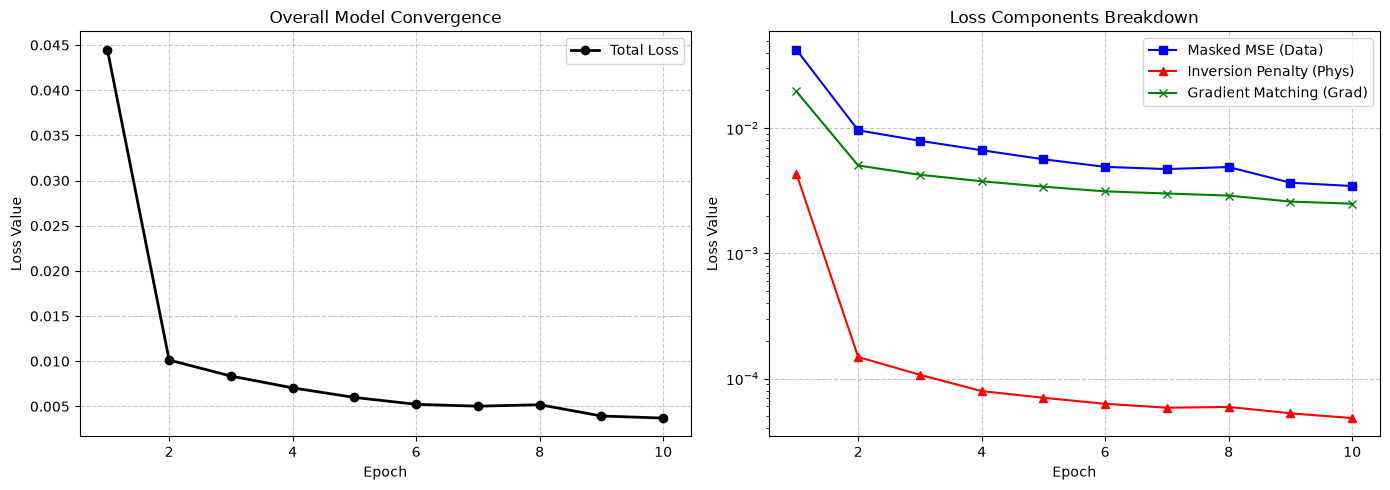

In [46]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# 1. Setup the Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Training on device: {device}")

# 2. Initialize the model
model = OceanEmbed(
    in_channels=8, 
    mixer_branches=16, 
    lstm_hidden=32, 
    target_channels=8, 
    out_depths=15
).to(device)

# 3. Initialize the expert Loss Engine
loss_engine = OceanPhysicsLoss(alpha_phys=0.05, beta_grad=0.1).to(device)

# 4. Define the Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 5. Ensure the static 3D mask is on the correct device
mask_3d_device = mask_3d_tensor.to(device)

# --- TRACKING LISTS FOR VISUALIZATION ---
history_total = []
history_data = []
history_phys = []
history_grad = []

# --- THE TRAINING LOOP ---
epochs = 10 
print("Starting Local Experiment Training...")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    running_l_data = 0.0
    running_l_phys = 0.0
    running_l_grad = 0.0
    
    for batch_idx, (batch_x_hist, batch_x_target, batch_y_target) in enumerate(train_loader):
        
        batch_x_hist = batch_x_hist.to(device)
        batch_x_target = batch_x_target.to(device)
        batch_y_target = batch_y_target.to(device)
        
        optimizer.zero_grad()
        
        pred_3d = model(batch_x_hist, batch_x_target)
        
        total_loss, l_data, l_phys, l_grad = loss_engine(pred_3d, batch_y_target, mask_3d_device)
        
        total_loss.backward()
        optimizer.step()
        
        running_loss += total_loss.item()
        running_l_data += l_data.item()
        running_l_phys += l_phys.item()
        running_l_grad += l_grad.item()
        
    # Calculate averages for the epoch
    num_batches = len(train_loader)
    avg_loss = running_loss / num_batches
    avg_data = running_l_data / num_batches
    avg_phys = running_l_phys / num_batches
    avg_grad = running_l_grad / num_batches
    
    # Store metrics for plotting
    history_total.append(avg_loss)
    history_data.append(avg_data)
    history_phys.append(avg_phys)
    history_grad.append(avg_grad)
    
    print(f"Epoch [{epoch+1}/{epochs}] | "
          f"Total: {avg_loss:.4f} | "
          f"Data: {avg_data:.4f} | "
          f"Phys: {avg_phys:.4f} | "
          f"Grad: {avg_grad:.4f}")

print("\nLocal training complete. Generating learning curves...")

# --- VISUALIZATION BLOCK ---
epochs_range = range(1, epochs + 1)
plt.figure(figsize=(14, 5))

# Plot 1: Total Loss Trajectory
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history_total, label='Total Loss', color='black', marker='o', linewidth=2)
plt.title('Overall Model Convergence')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Plot 2: Loss Components Breakdown
plt.subplot(1, 2, 2)
plt.plot(epochs_range, history_data, label='Masked MSE (Data)', color='blue', marker='s')
plt.plot(epochs_range, history_phys, label='Inversion Penalty (Phys)', color='red', marker='^')
plt.plot(epochs_range, history_grad, label='Gradient Matching (Grad)', color='green', marker='x')
plt.title('Loss Components Breakdown')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.yscale('log') # Log scale helps visualize small physics penalties alongside larger MSE
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

Starting Local Experiment Training with Micro Logs...

=== Epoch [1/10] ===
  -> Batch [ 50/271] | Micro Loss: 0.0565
  -> Batch [100/271] | Micro Loss: 0.0305
  -> Batch [150/271] | Micro Loss: 0.0153
  -> Batch [200/271] | Micro Loss: 0.0139
  -> Batch [250/271] | Micro Loss: 0.0100
[*] Epoch 1 Completed | Avg Total: 0.0696 | Data: 0.0672 | Phys: 0.0059 | Grad: 0.0202

=== Epoch [2/10] ===
  -> Batch [ 50/271] | Micro Loss: 0.0095
  -> Batch [100/271] | Micro Loss: 0.0094
  -> Batch [150/271] | Micro Loss: 0.0105
  -> Batch [200/271] | Micro Loss: 0.0079
  -> Batch [250/271] | Micro Loss: 0.0096
[*] Epoch 2 Completed | Avg Total: 0.0096 | Data: 0.0092 | Phys: 0.0002 | Grad: 0.0047

=== Epoch [3/10] ===
  -> Batch [ 50/271] | Micro Loss: 0.0086
  -> Batch [100/271] | Micro Loss: 0.0057
  -> Batch [150/271] | Micro Loss: 0.0065
  -> Batch [200/271] | Micro Loss: 0.0063
  -> Batch [250/271] | Micro Loss: 0.0068
[*] Epoch 3 Completed | Avg Total: 0.0078 | Data: 0.0074 | Phys: 0.0001 | Gr

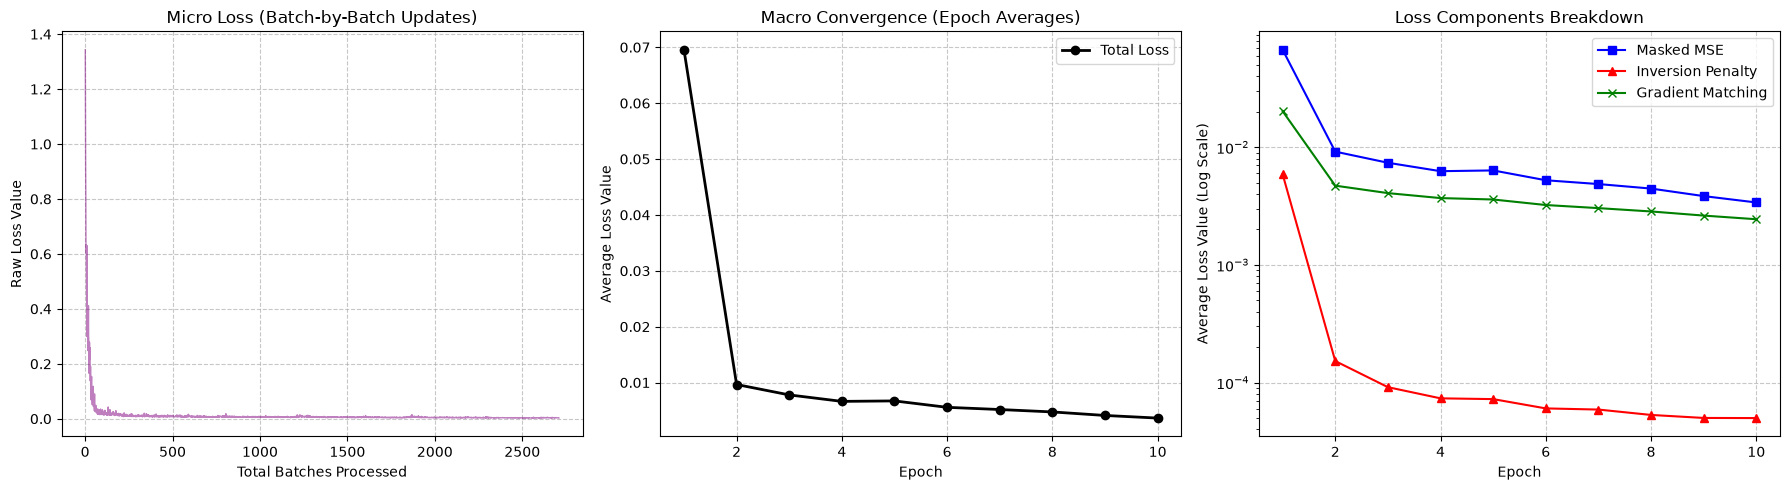

In [48]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Setup the Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 2. Initialize the model
model = OceanEmbed(
    in_channels=8, 
    mixer_branches=16, 
    lstm_hidden=32, 
    target_channels=8, 
    out_depths=15
).to(device)

# 3. Initialize the expert Loss Engine
loss_engine = OceanPhysicsLoss(alpha_phys=0.05, beta_grad=0.1).to(device)

# 4. Define the Optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Ensure the static 3D mask is on the correct device
mask_3d_device = mask_3d_tensor.to(device)

# --- TRACKING LISTS FOR VISUALIZATION ---
history_total_epoch = []
history_data_epoch = []
history_phys_epoch = []
history_grad_epoch = []
history_micro_batch = [] 

# --- THE TRAINING LOOP ---
epochs = 10 
num_batches = len(train_loader)
print("Starting Local Experiment Training with Micro Logs...\n")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    running_l_data = 0.0
    running_l_phys = 0.0
    running_l_grad = 0.0
    
    print(f"=== Epoch [{epoch+1}/{epochs}] ===")
    
    for batch_idx, (batch_x_hist, batch_x_target, batch_y_target) in enumerate(train_loader):
        
        batch_x_hist = batch_x_hist.to(device)
        batch_x_target = batch_x_target.to(device)
        batch_y_target = batch_y_target.to(device)
        
        optimizer.zero_grad()
        
        pred_3d = model(batch_x_hist, batch_x_target)
        
        total_loss, l_data, l_phys, l_grad = loss_engine(pred_3d, batch_y_target, mask_3d_device)
        
        total_loss.backward()
        optimizer.step()
        
        running_loss += total_loss.item()
        running_l_data += l_data.item()
        running_l_phys += l_phys.item()
        running_l_grad += l_grad.item()
        
        history_micro_batch.append(total_loss.item())
        
        # MICRO LOG: Print update every 50 batches
        if (batch_idx + 1) % 50 == 0:
            print(f"  -> Batch [{batch_idx + 1:3d}/{num_batches}] | Micro Loss: {total_loss.item():.4f}")
            
    # Macro Epoch Logging
    avg_loss = running_loss / num_batches
    avg_data = running_l_data / num_batches
    avg_phys = running_l_phys / num_batches
    avg_grad = running_l_grad / num_batches
    
    history_total_epoch.append(avg_loss)
    history_data_epoch.append(avg_data)
    history_phys_epoch.append(avg_phys)
    history_grad_epoch.append(avg_grad)
    
    print(f"[*] Epoch {epoch+1} Completed | Avg Total: {avg_loss:.4f} | Data: {avg_data:.4f} | Phys: {avg_phys:.4f} | Grad: {avg_grad:.4f}\n")

print("Local training complete. Generating expanded learning curves...")

# --- VISUALIZATION BLOCK ---
epochs_range = range(1, epochs + 1)
batches_range = range(1, len(history_micro_batch) + 1)

plt.figure(figsize=(18, 5))

# Plot 1: Micro Batch Loss
plt.subplot(1, 3, 1)
plt.plot(batches_range, history_micro_batch, color='purple', alpha=0.5, linewidth=1)
plt.title('Micro Loss (Batch-by-Batch Updates)')
plt.xlabel('Total Batches Processed')
plt.ylabel('Raw Loss Value')
plt.grid(True, linestyle='--', alpha=0.7)

# Plot 2: Epoch Average Total Loss
plt.subplot(1, 3, 2)
plt.plot(epochs_range, history_total_epoch, label='Total Loss', color='black', marker='o', linewidth=2)
plt.title('Macro Convergence (Epoch Averages)')
plt.xlabel('Epoch')
plt.ylabel('Average Loss Value')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Plot 3: Loss Components Breakdown
plt.subplot(1, 3, 3)
plt.plot(epochs_range, history_data_epoch, label='Masked MSE', color='blue', marker='s')
plt.plot(epochs_range, history_phys_epoch, label='Inversion Penalty', color='red', marker='^')
plt.plot(epochs_range, history_grad_epoch, label='Gradient Matching', color='green', marker='x')
plt.title('Loss Components Breakdown')
plt.xlabel('Epoch')
plt.ylabel('Average Loss Value (Log Scale)')
plt.yscale('log')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()